In [ ]:
import sys
#sys.path.append("../../..")
sys.path.append("/home/pra06853/pycrp/pyCRP/")
from pycrp.io_user import io_CUTE_prodDCRC as io
import numpy as np # Numerical data analysis library
import matplotlib.pyplot as plt # Plottling library
import joblib # Used to open processed data RQs
#import event_reader # Wrapper to read raw data traces with settings relevant for nexus
import glob # Used to access saved files in directory
from scipy import signal # Used to run a butterworth filter on the template trace
import inspect # Useful library to see what functions do, i.e. below
#print(inspect.getsource(event_reader.get_raw_traces_nr7))
#print(inspect.getsource(io.getRawEvents))
import pycrp
import scipy
from pycrp.io_user import io_NEXUS #Used to examine raw traces before making Chi2 cuts
import matplotlib as mlp
import matplotlib.colors as mcolors
sys.path.append('/sdf/home/k/ktk/notebook/Nexus/R15/DMLimits/HVeV-analysis')
#import signalFloor as cpd
import pandas as pd
import matplotlib.cm as cm
plt.rcParams['xtick.labelsize']=15
plt.rcParams['ytick.labelsize']=15

import qetpy as qp

import pickle
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
mpl.rcParams['figure.figsize'] = [10, 6.5]

import numpy as np
import pandas as pd
from pprint import pprint
import astropy
#import vaex as vx
#from detanalysis import Analyzer
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

#from IPython.display import IFrame
import warnings
warnings.filterwarnings('ignore')
import joblib as joblib
from scipy.signal import butter, filtfilt
#fft stuff
from scipy.fftpack import fft, ifft, fftfreq

from qetpy.utils import shift

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colorbar import Colorbar
from matplotlib.backends.backend_pdf import PdfPages

QETPy Installed. NxM OF can be used to fit on triggered Pulses
nptdms not available, skip for Argonne data.
No local midas libary installed
Using IO script at: /home/pra06853/.local/lib/python3.10/site-packages/pycrp/io_user/io_CUTE_prodDCRC.py
Importing rawio directly
Using IO script at: /home/pra06853/.local/lib/python3.10/site-packages/pycrp/io_user/io_NEXUS.py
Importing rawio directly


In [ ]:
# More libs:
from pycrp.include_modules import *       # Import a list of modules
#color=Utils.color
# from pycrp.include_modules_root import *  # Import a list of pyROOT modules and functions

# Enable inline plots
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

Importing rawio directly


In [ ]:
### Initialize

procdir="/project/def-zqhong/data/CUTE/R40/processed/" # directory where pre-processed data RQs end up
rawdir="/project/def-zqhong/data/CUTE/R40/Raw/" # Raw data directory. Used later to load the good traces
#template=joblib.load(open('/project/def-zqhong/data/CUTE/R40/processed/Templates/Template_v7.joblib', "rb" ))
template=joblib.load(open('/project/def-zqhong/data/CUTE/R40/reprocessed_v2/templates/FinalTemplate_v1.joblib', "rb" ))

series='23240801_210238' # series number

HV = -45 #V
data = joblib.load( open( procdir+"OFResults_"+series+".joblib" , 'rb' ) ) # Loading the pre-processed data into python dictionary
PSD = joblib.load(open(procdir+"PSDs_"+series+".joblib","rb"))

pycrp.add_rrq(data)
data['timestamp_corr'] =  pycrp.fix_timestamps(data['timestamp'], first_eventtime = min(data['timestamp']), sf=625000);


chlist=["Random", "NFH_total", "NFC1_total", "NFC2_total", "NFE_out", "NFH_SO_in", "NFC_SO_total"]

#actually what kyle had
chsHV = ['NFH_total','NFC1_total', 'NFC2_total', 'NFE_out', "NFH_SO_in", 'NFC_SO_total'] #These are the channels which had the HV



trig_ch = {}
trig_ch['Random'] = 0
trig_ch["NFH_total"] = 1
trig_ch["NFC1_total"] = 2
trig_ch["NFC2_total"] = 3
trig_ch["NFE_out"] = 4
trig_ch["NFH_SO_in"] = 5
trig_ch["NFC_SO_total"] = 6




mask_trig = {}
for ch in chlist:
    mask_trig[ch] = (data['trig_ch'] == trig_ch[ch])


In [ ]:
procdir+"PSDs_"+series+".joblib"

'/project/def-zqhong/data/CUTE/R40/processed/PSDs_23240801_210238.joblib'

In [ ]:
Noise_dict = np.load('Noise_dict_from_random_traces_baseline_not_subtracted.npy',allow_pickle=True)
noise_csd= Noise_dict.item()['noise_csd']

noise_frequecy= Noise_dict.item()['noise_frequecy']
noise_csd.shape


(2, 2, 2048)

In [ ]:
PSD_NFC_SO_out= np.copy(Noise_dict.item()['noise_csd'][0][0])
PSD_NFC_SO_in= np.copy(Noise_dict.item()['noise_csd'][1][1])

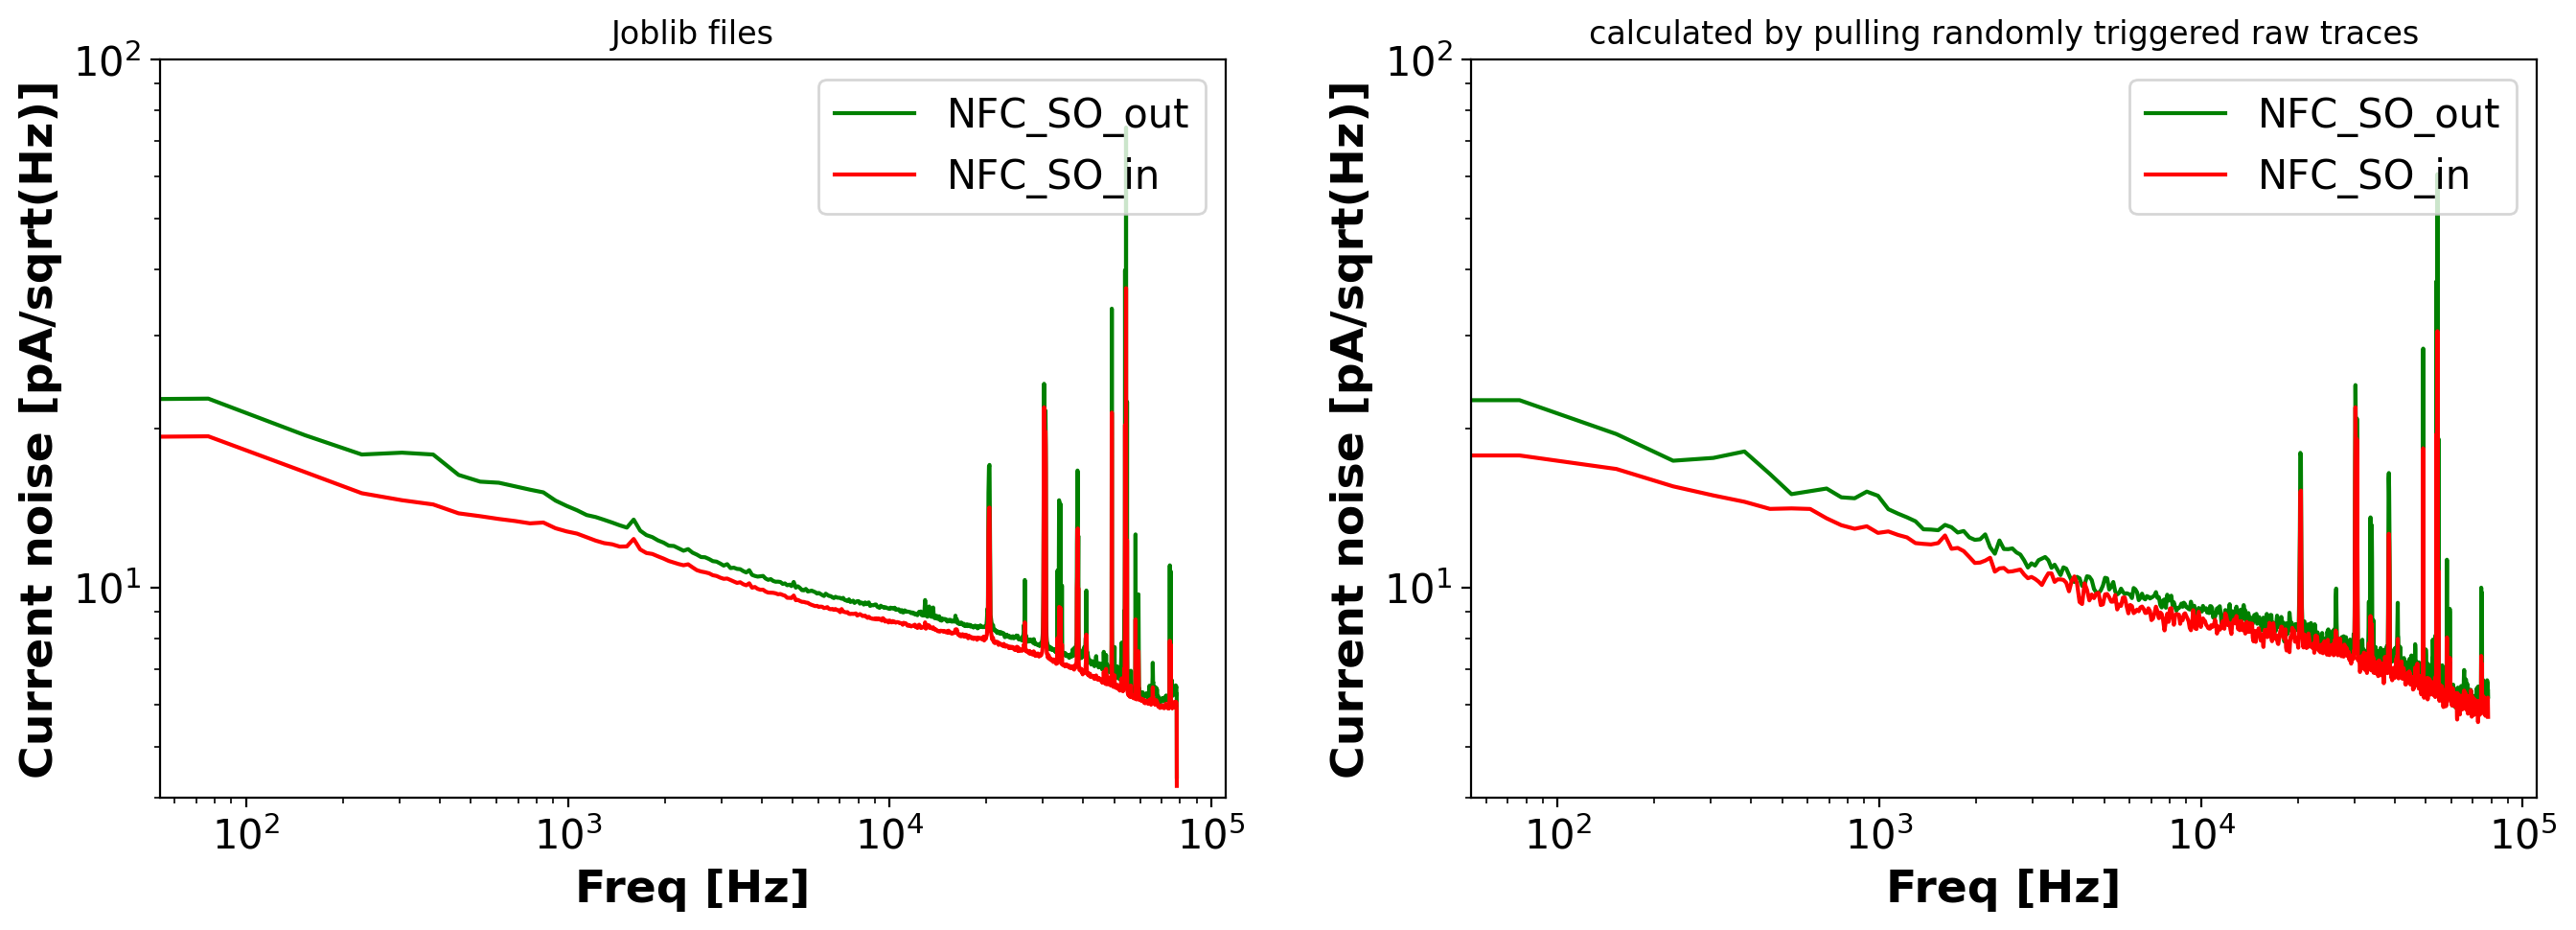

In [ ]:
# Create a figure
fig = plt.figure(1,figsize=(16,5))

gs=GridSpec(4,4)
gs.update(wspace=0.6,hspace=0.5)

##first plot#####
xtr_subplot =fig.add_subplot(gs[0:4,0:2])

# Plot each array with a unique color
for i, (key, values) in enumerate(PSD['PSDs'].items()):
    #print(key)
    if (key == "NFC_SO_in"):
        plt.plot(PSD['f'], values/np.sqrt(2), label=key, color='r')
    if (key == "NFC_SO_out"):
        plt.plot(PSD['f'], values/np.sqrt(2), label=key, color='g')

# Add labels and title
plt.ylabel(r'Current noise [pA/sqrt(Hz)]',fontsize=17,fontweight='bold')
#plt.ylabel(r'??',fontsize=17,fontweight='bold')
plt.xlabel(r'Freq [Hz]',fontsize=17,fontweight='bold')
plt.title('Joblib files')
plt.legend(loc='upper right',fontsize='15')  # Position legend outside the plot
plt.xscale("log")
plt.yscale("log")
plt.ylim(4,1e2)




##first plot#####
xtr_subplot =fig.add_subplot(gs[0:4,2:4])


f_cutoff= int(len(noise_frequecy)/2)

plt.plot(noise_frequecy[:f_cutoff], np.sqrt(PSD_NFC_SO_out[:f_cutoff])*1e12,color = 'g', label = "NFC_SO_out" )
plt.plot(noise_frequecy[:f_cutoff], np.sqrt(PSD_NFC_SO_in[:f_cutoff])*1e12,color = 'r', label = "NFC_SO_in" )


plt.xlabel(r'Freq [Hz]',fontsize=17,fontweight='bold')
plt.ylabel(r'Current noise [pA/sqrt(Hz)]',fontsize=17,fontweight='bold')
plt.title('calculated by pulling randomly triggered raw traces')
plt.legend(loc='upper right',fontsize='15')  # Position legend outside the plot
plt.xscale("log")
plt.yscale("log")
plt.ylim(4,1e2)

plt.tight_layout()
plt.show()


In [ ]:
#to get time in sec
sampling_rate = 625000/4
pretrigger_samples= int(4096/4)
posttrigger_samples = int(4096/4)
#t=np.arange(-pretrigger_samples/sampling_rate,(df['raw_pulses'].shape[1]-pretrigger_samples-1)/sampling_rate,1/sampling_rate)
t=np.arange(-pretrigger_samples/sampling_rate,posttrigger_samples/sampling_rate,1/sampling_rate)

t.shape




(2048,)

(-0.05, 1.2)

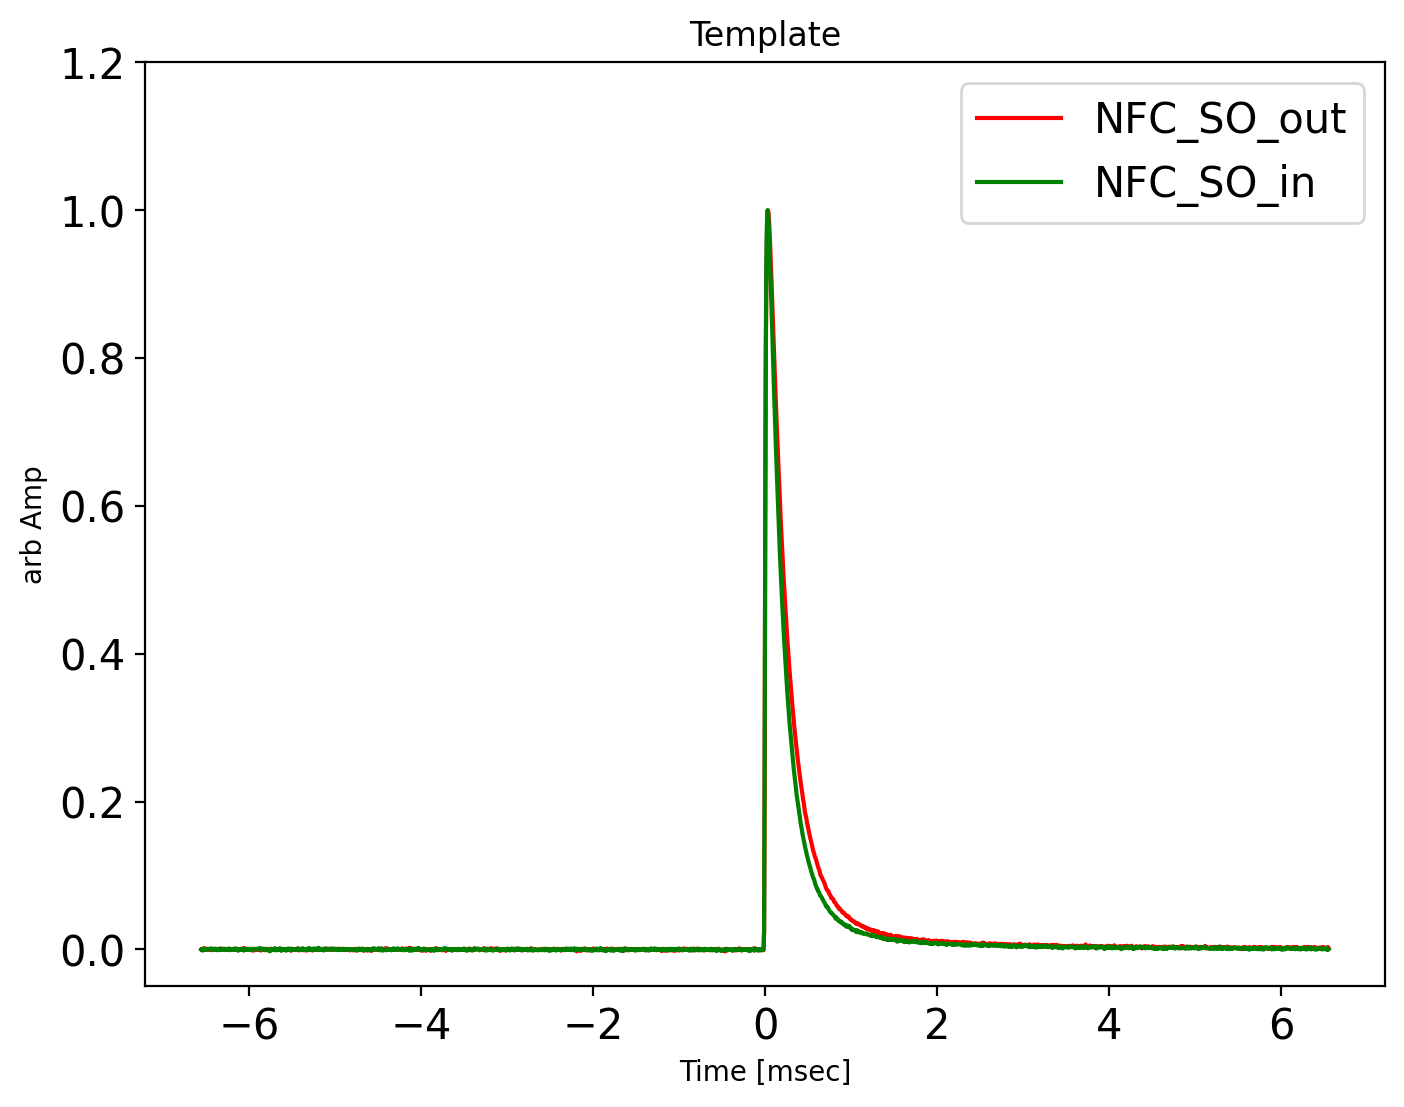

In [ ]:

# Create a figure
plt.figure(figsize=(8, 6))

# Plot each array with a unique color
for i, (key, values) in enumerate(template.items()):
    #print(key)
    if (key == "NFC_SO_in"):
        plt.plot( t*1e3, values, label=key, color='g')
    if (key == "NFC_SO_out"):
        plt.plot( t*1e3, values, label=key, color='r')

# Add labels and title
plt.xlabel('Time [msec]')
plt.ylabel('arb Amp')
plt.title('Template')
plt.legend(loc='upper right',fontsize='15')  # Position legend outside the plot
#plt.xscale("log")
#plt.yscale("log")
plt.ylim(-0.05,1.2)


In [ ]:
Template_NFC_SO_out=template["NFC_SO_out"]
Template_NFC_SO_in=template["NFC_SO_in"]

In [ ]:
# Define the file path

config_str = open("/project/def-zqhong/data/CUTE/R40/reprocessed_v1/configs/HVeVCUTE_R40_v1.py").read()
exec(config_str, globals())

config.trigger_threshold

{'NFH_total': 0.055,
 'NFC1_total': 0.137,
 'NFC2_total': 0.099,
 'NFE_out': 0.08,
 'NFH_SO_in': 0.05,
 'NFC_SO_total': 0.1,
 'LED_dummy': 0.05}

In [ ]:
# Define the grid range in log scale
x = np.logspace(-9, -6, 40)  # 100 points from 1e-9 to 1e-5
y = np.logspace(-9, -6, 40)

# Create the grid
X, Y = np.meshgrid(x, y)
#for x in X:#
#    for y in Y:
#        print(x,y)

In [ ]:
#noise = qp.gen_noise(PSD_NFC_SO_out, fs=sampling_rate, n_traces=1)
noise = qp.gen_noise(noise_csd, fs=sampling_rate, n_traces=1)
noise.shape

(1, 2, 2048)

In [ ]:
def get_sum_fake_traces_in_uA(A,B):
    '''
    A and B are the amplitude
    of Each pulse in Ampere.
    '''
    #noise1 = qp.gen_noise(PSD_NFC_SO_out, fs=sampling_rate)
    #noise2 = qp.gen_noise(PSD_NFC_SO_in, fs=sampling_rate)
    noise = qp.gen_noise(noise_csd, fs=sampling_rate, n_traces=1)
    return (noise[0][0][:] + A*Template_NFC_SO_out + noise[0][1][:] + B*Template_NFC_SO_in)*1e6


def boolean_is_there_a_trigger(A,B):
    '''
    A and B are the amplitude
    of Each pulse in Ampere.
    '''
    # Process the trace
    tra = get_sum_fake_traces_in_uA(A,B)  # provide the sum of trace in uA
    MeanBase = np.mean(tra[0:500])  # Calculate the baseline mean
    Filtered = scipy.signal.correlate(tra, Try_Kernel, mode="same").astype(np.float32)

    # Identify trigger points
    trigger_points = np.flatnonzero((Filtered[0:-1] < trig_th) & (Filtered[1:] > trig_th)) + 1
    trigger_points_aligned = []
    trigger_amp_aligned = []
    trigger_widths = []

    # Align triggers
    for trigpt in trigger_points:
        if trigpt < (len(Filtered) - peak_search_window_limit):
            search_window = np.argmax(Filtered[trigpt:trigpt + peak_search_window_limit] < deactivate_th)
            if search_window == 0:
                search_window = peak_search_window_limit
            offset = np.argmax(Filtered[trigpt:trigpt + search_window])
            trigger_points_aligned.append(trigpt + offset)
            trigger_amp_aligned.append(Filtered[trigger_points_aligned[-1]])
            trigger_widths.append(search_window)

    # Remove duplicates
    trigger_points_aligned, mask = np.unique(trigger_points_aligned, return_index=True)
    trigger_points_final = trigger_points_aligned.astype(float)
    trigger_amp_final = np.array(trigger_amp_aligned)[mask]
    trigger_widths_final = np.array(trigger_widths).astype(float)[mask]

    return trigger_points_final.shape[0] != 0


def get_trigger_eff(N,i,j):
    '''
    N represents Number of trials
    i and j are the indices that run through the current matrix grid
    '''
    true_triggers=np.zeros(N)
    for n in range(N):
        true_triggers[n] = boolean_is_there_a_trigger(X[i][j],Y[i][j])
    return np.count_nonzero(true_triggers)/N

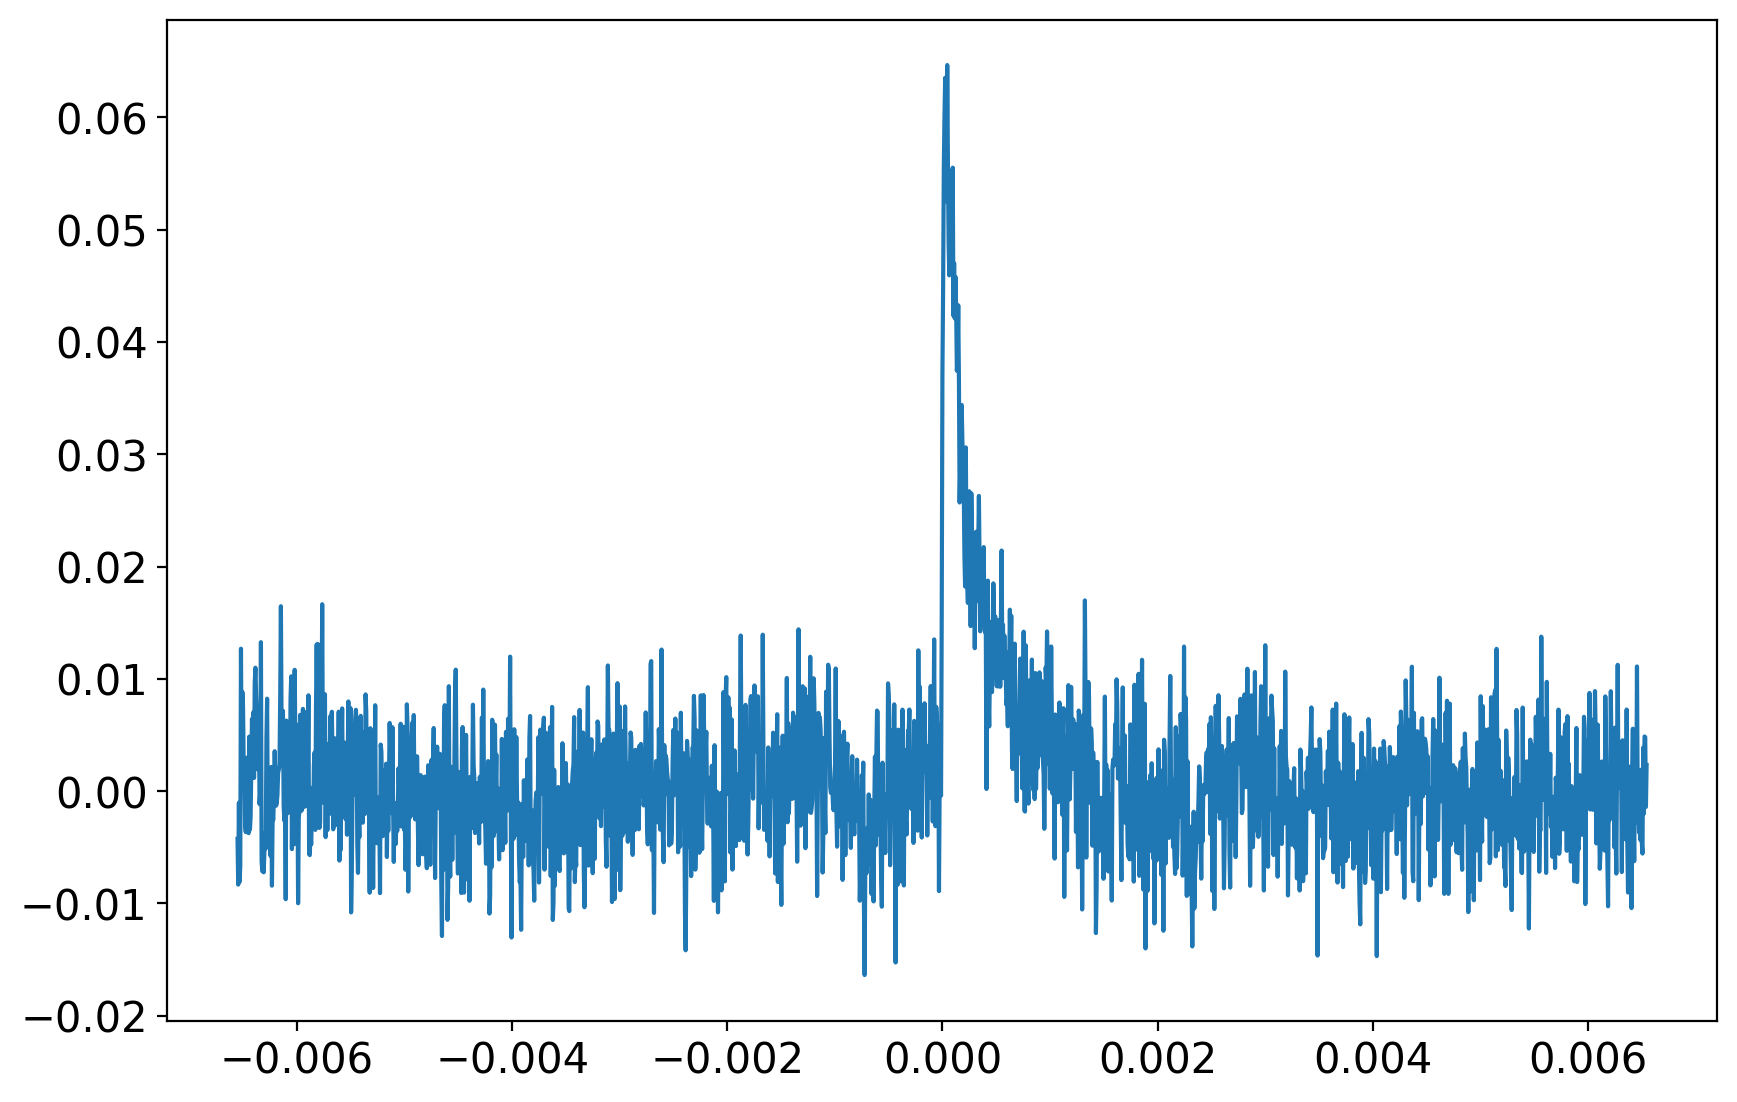

In [ ]:
plt.plot(t,  get_sum_fake_traces_in_uA(X[19][19],Y[19][19]))

In [ ]:
config.trigger_peak_search_window

1024

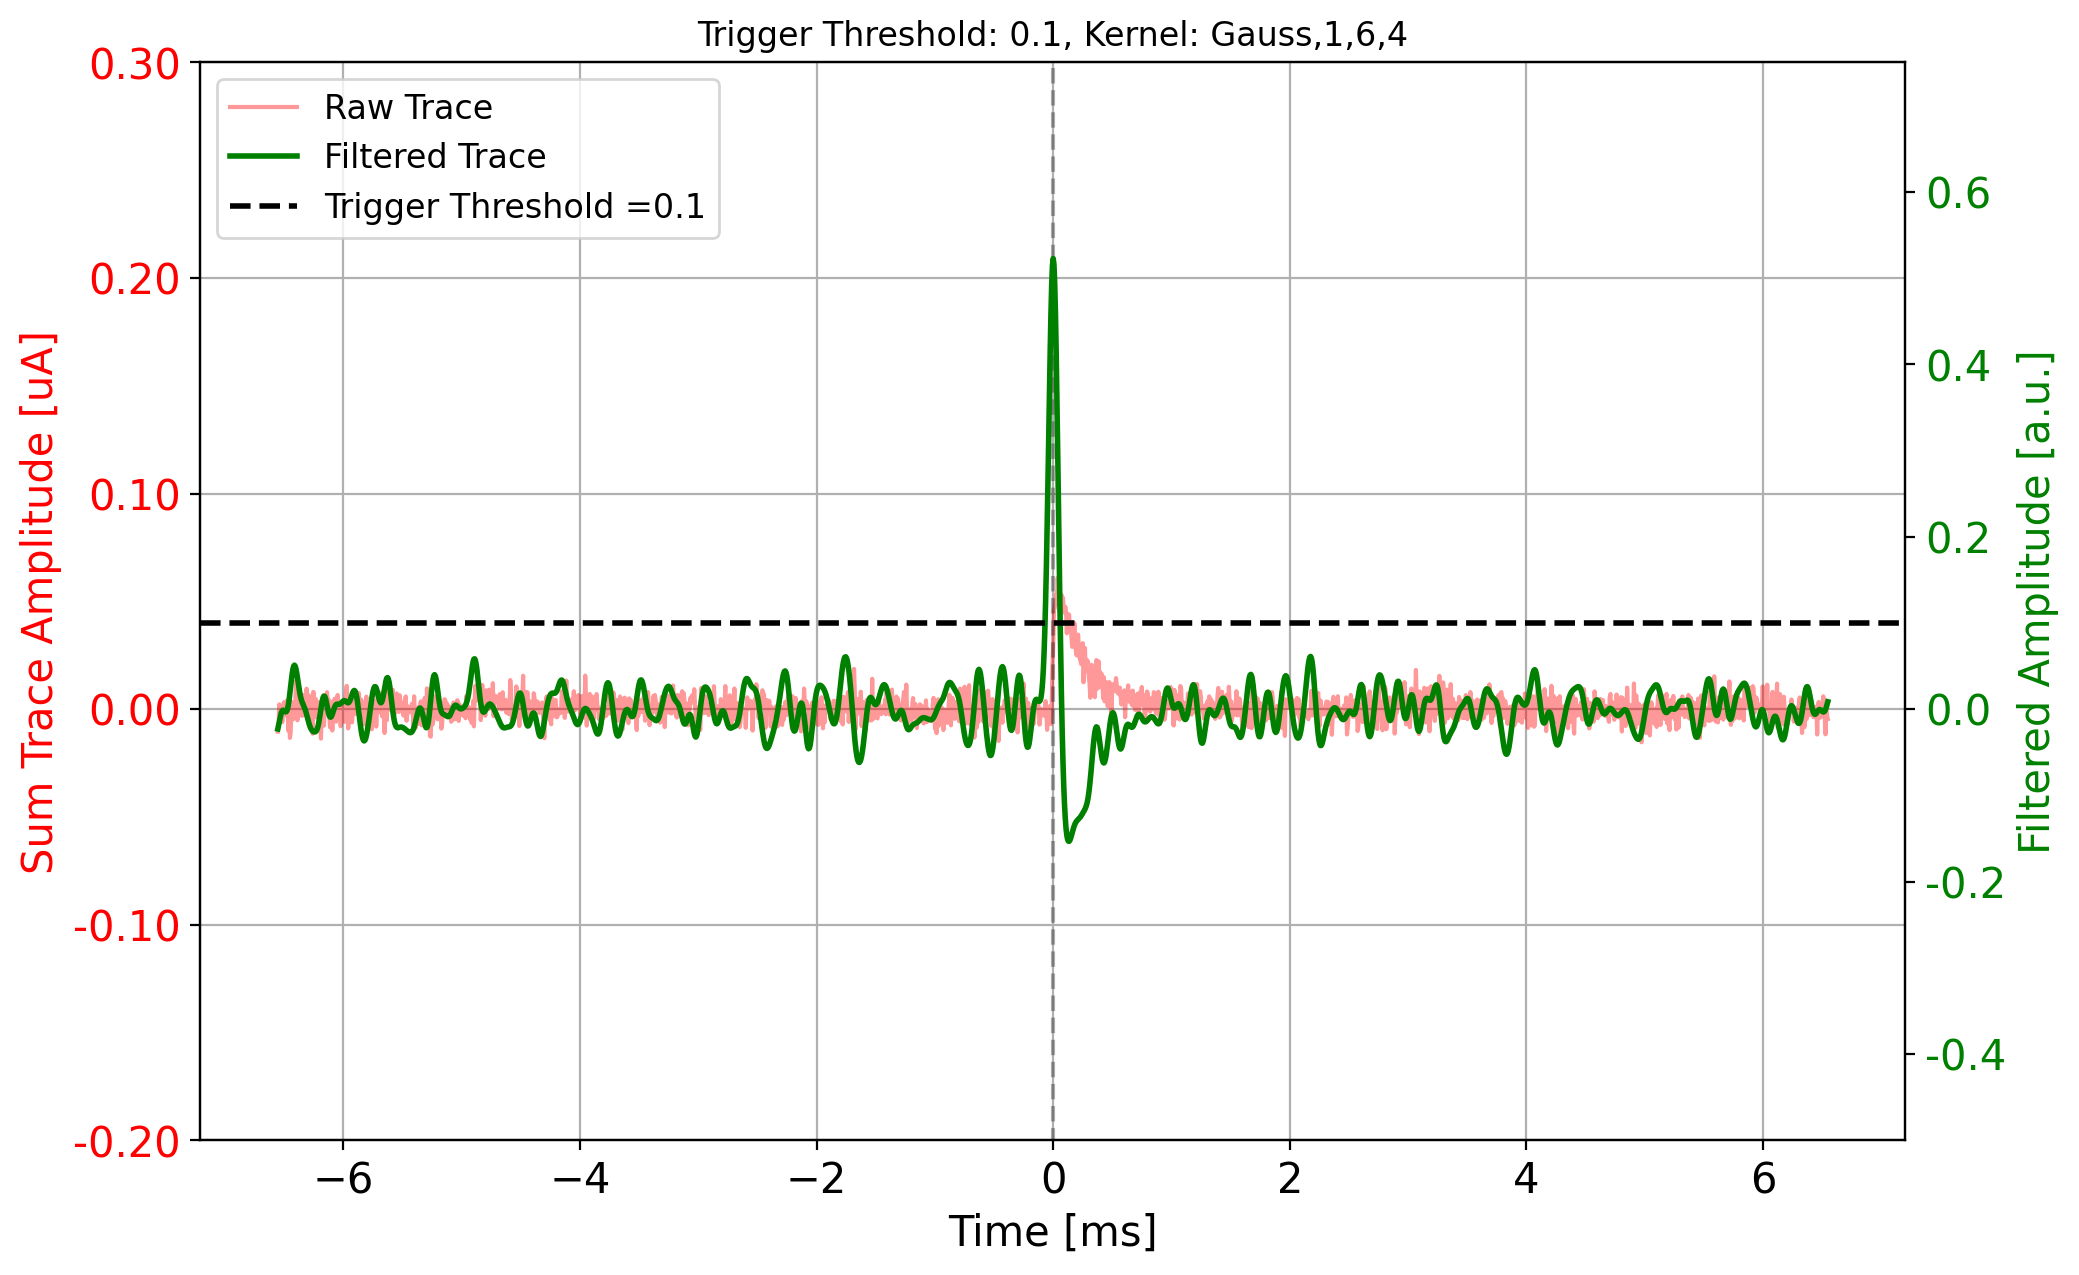

In [ ]:
# Gaussian kernel for filtering
trigger_instance = pycrp.Trigger()

# Call the method on the instance
Try_Kernel = trigger_instance._make_kernel_gauss(gaus_order=1, gaus_sigma=6, gaus_truncate=4)

# Initialize variables
trig_th = config.trigger_threshold['NFC_SO_total']  # Example threshold
peak_search_window_limit = config.trigger_peak_search_window  # 10  # Window to refine trigger alignment
deactivate_th = config.trigger_threshold_deact  # 0  # Deactivation threshold for trigger alignment

# Process the trace
tra = get_sum_fake_traces_in_uA(X[19][19],Y[19][19])  # provide the sum of trace in uA
MeanBase = np.mean(tra[0:500])  # Calculate the baseline mean
Filtered = scipy.signal.correlate(tra, Try_Kernel, mode="same").astype(np.float32)

# Identify trigger points
trigger_points = np.flatnonzero((Filtered[0:-1] < trig_th) & (Filtered[1:] > trig_th)) + 1
trigger_points_aligned = []
trigger_amp_aligned = []
trigger_widths = []

# Align triggers
for trigpt in trigger_points:
    if trigpt < (len(Filtered) - peak_search_window_limit):
        search_window = np.argmax(Filtered[trigpt:trigpt + peak_search_window_limit] < deactivate_th)
        if search_window == 0:
            search_window = peak_search_window_limit
        offset = np.argmax(Filtered[trigpt:trigpt + search_window])
        trigger_points_aligned.append(trigpt + offset)
        trigger_amp_aligned.append(Filtered[trigger_points_aligned[-1]])
        trigger_widths.append(search_window)

# Remove duplicates
trigger_points_aligned, mask = np.unique(trigger_points_aligned, return_index=True)
trigger_points_final = trigger_points_aligned.astype(float)
trigger_amp_final = np.array(trigger_amp_aligned)[mask]
trigger_widths_final = np.array(trigger_widths).astype(float)[mask]

# Visualization
fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111)

#ax.plot((np.arange(len(tra)) - 1024) * 0.0064, tra-np.mean(tra), label='Raw Trace')
ax.plot(t*1e3, tra, label='Raw Trace', color='red' ,alpha =0.4)


#ax.plot(t_trig_ms, Savgol_Filtered-np.mean(Savgol_Filtered), color='magenta', label='savgol Filtered Trace', lw=2)

ax.vlines((np.array(trigger_points_final)- pretrigger_samples) * 1/sampling_rate*1e3, \
                      -500, 500, linestyle='dashed', color='k', alpha =0.3)


# Add legends
ax.set_xlabel('Time [ms]', fontsize=15)

yticks = [-0.2,-0.1,0,0.1,0.2, 0.3]  # Specify the yticks
ax.set_yticks(yticks)  # Set the yticks
ax.set_yticklabels([f"{tick:.2f}" for tick in yticks], color='red')  # Set labels and color

ax.set_ylim(-0.2, 0.3)


ax.set_title("Trigger Threshold: " +str(trig_th) +", Kernel: "+config.trigger_kernel )
ax.grid()

# Add filtered trace
ax_filt = ax.twinx()

ax_filt.plot(t*1e3, Filtered, color='green', label='Filtered Trace', lw=2)
ax_filt.axhline(trig_th, color='black', linestyle='dashed', lw=2, label='Trigger Threshold =' + str(trig_th) )
ax_filt.set_yticks([])
ax_filt.set_ylim(-0.50, 0.75)

ax.set_ylabel('Sum Trace Amplitude [uA]', fontsize=15,color='red')
ax_filt.set_ylabel('Filtered Amplitude [a.u.]', fontsize=15,color='green')

yticks = [-0.40,-0.20,0,0.20,0.40,0.60]  # Specify the yticks
ax_filt.set_yticks(yticks)  # Set the yticks
ax_filt.set_yticklabels([f"{tick:.1f}" for tick in yticks], color='green')  # Set labels and color




#ax.legend(loc=0, fontsize=12)
#ax_filt.legend(loc=[0.7, 0.7], fontsize=12)

# Get handles and labels for both axes
handles, labels = ax.get_legend_handles_labels()
handles_filt, labels_filt = ax_filt.get_legend_handles_labels()

# Combine handles and labels
ax.legend(handles=handles + handles_filt, labels=labels + labels_filt, loc='upper left', fontsize=12)



ax_filt.grid(False)
#ax.set_xlim(-2, 4)
plt.show()

In [ ]:
trigger_points_final

array([1024.])

In [ ]:
N=100
true_triggers=np.zeros(N)
for i in range(N):
    true_triggers[i] = boolean_is_there_a_trigger(X[19][9],Y[19][9])
np.count_nonzero(true_triggers)

100

In [ ]:
get_trigger_eff(100,4,4)

0.0

In [ ]:
N = 100
Z = np.zeros_like(X)
for i in range(len(X[0])):
    print("{0}% is completed".format(i))
    for j in range(len(X.T[0])):
        Z[i][j]= get_trigger_eff(N,i,j)*100


#Z[i][j]=np.count_nonzero(true_triggers)/N

0% is completed
1% is completed
2% is completed
3% is completed
4% is completed
5% is completed
6% is completed
7% is completed
8% is completed
9% is completed
10% is completed
11% is completed
12% is completed
13% is completed
14% is completed
15% is completed
16% is completed
17% is completed
18% is completed
19% is completed
20% is completed
21% is completed
22% is completed
23% is completed
24% is completed
25% is completed
26% is completed
27% is completed
28% is completed
29% is completed
30% is completed
31% is completed
32% is completed
33% is completed
34% is completed
35% is completed
36% is completed
37% is completed
38% is completed
39% is completed


In [ ]:
#np.save("eff_100mcSteps_40_40_Grid_newer_template", Z)
Z=np.load("eff_100mcSteps_40_40_Grid_newer_template.npy")
Z

array([[  0.,   0.,   0., ..., 100., 100., 100.],
       [  0.,   0.,   0., ..., 100., 100., 100.],
       [  0.,   0.,   0., ..., 100., 100., 100.],
       ...,
       [100., 100., 100., ..., 100., 100., 100.],
       [100., 100., 100., ..., 100., 100., 100.],
       [100., 100., 100., ..., 100., 100., 100.]])

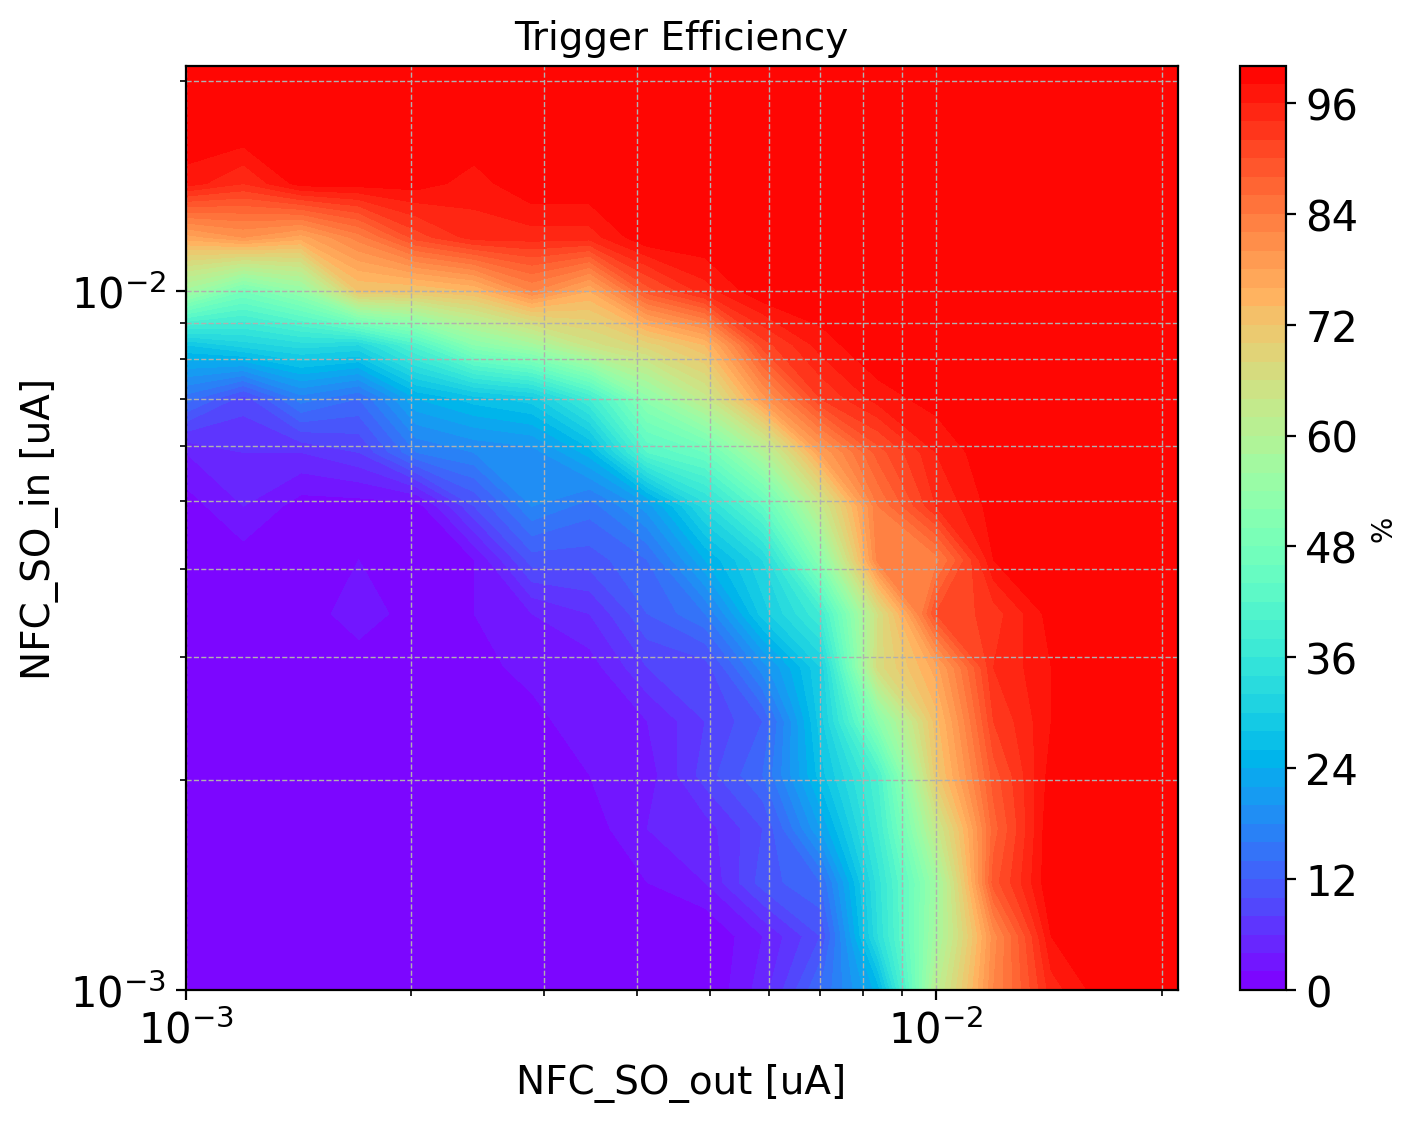

In [ ]:
# Plot the grid
plt.figure(figsize=(8, 6))
#plt.contourf(X*1e6, Y*1e6, Z, levels=50, cmap="viridis")  # Filled contour plot
plt.contourf(X*1e6, Y*1e6, Z, levels=50, cmap="rainbow")  # Filled contour plot
#contour = plt.contourf(X, Y, Z, levels=50, cmap="viridis", norm=LogNorm(vmin=1e-1, vmax=Z.max()))

# Set log scale
plt.xscale("log")
plt.yscale("log")

# Add labels and title
plt.xlabel("NFC_SO_out [uA]", fontsize=14)
plt.ylabel("NFC_SO_in [uA]", fontsize=14)
plt.title("Trigger Efficiency", fontsize=14)

# Add colorbar
plt.colorbar(label="%")
plt.xlim(1e-9*1e6,2.1*1e-8*1e6)
plt.ylim(1e-9*1e6,2.1*1e-8*1e6)
plt.grid(visible=True, which="both", linestyle="--", linewidth=0.5)
plt.show()

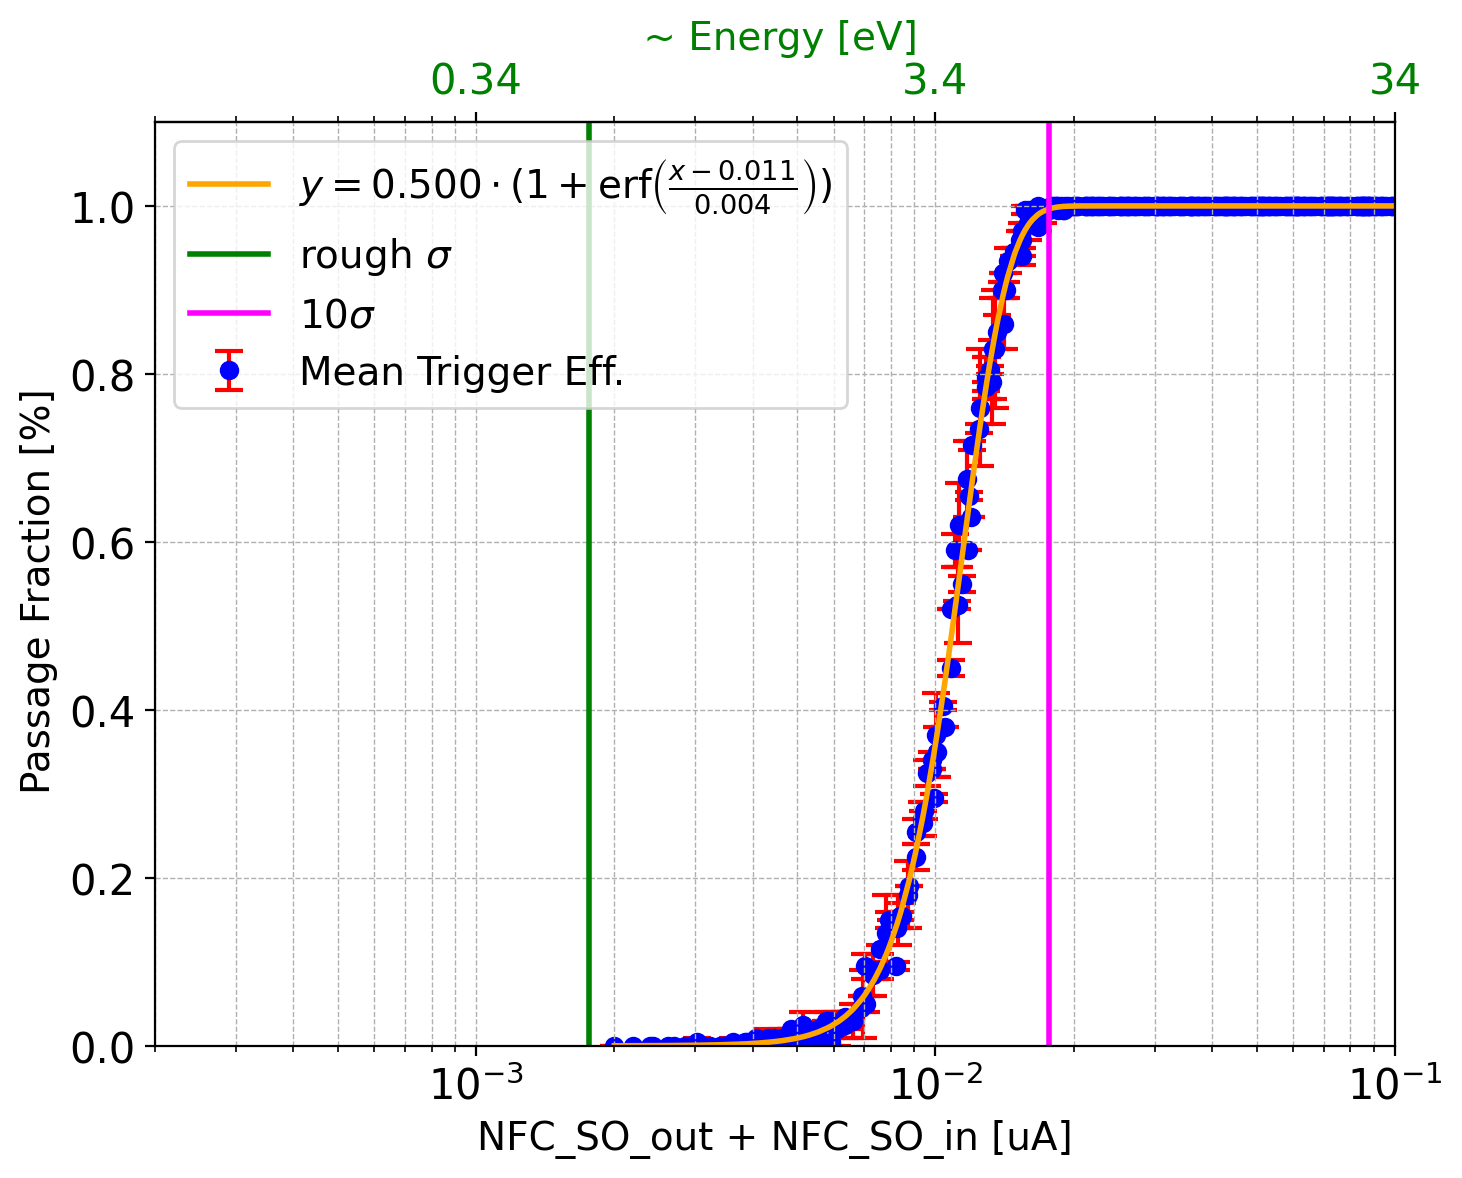

In [ ]:
# Element-wise sum of X and Y, then flatten to 1D array
XY_sum = (X + Y).flatten()
Z_flat = Z.flatten()

# Sort XY_sum in increasing order and track Z accordingly
sorted_indices = np.argsort(XY_sum)  # Get sorted indices
XY_sorted = XY_sum[sorted_indices]   # Sort XY_sum
Z_sorted = Z_flat[sorted_indices]    # Sort Z using the same indices

# Get unique values and statistics (mean and standard deviation)
XY_unique, indices = np.unique(XY_sorted, return_index=True)  # Unique values and first occurrence index
Z_mean = np.array([Z_sorted[XY_sorted == val].mean()/100 for val in XY_unique])  # Mean for duplicates
Z_std = np.array([Z_sorted[XY_sorted == val].std()/100 for val in XY_unique])   # Standard deviation for duplicates

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Plot XY_unique vs Z_mean with error bars
ax.errorbar(
    XY_unique*1e6, Z_mean, yerr=Z_std, fmt="o", color='b',capsize=5, capthick=1.5,
    ecolor="red", label="Mean Trigger Eff.", zorder=1)

equation = rf"$y = {popt[0]:.3f} \cdot (1 + \mathrm{{erf}}\left(\frac{{x - {popt[1]:.3f}}}{{{popt[2]:.3f}}}\right))$"

ax.plot(XY_unique*1e6, y_fit, label=equation, color='orange', linewidth=2, zorder=2)

# Set logarithmic scales
ax.set_xscale("log")
#ax.set_yscale("log")

# Add a duplicate x-axis below the current one
ax_bottom = ax.secondary_xaxis('top')
#ax_bottom.set_xscale("log")
ax_bottom.set_xlim(ax.get_xlim())

# Multiply tick marks by 0.34 for the bottom x-axis
ax_bottom.set_xticks(ax.get_xticks())
ax_bottom.set_xticklabels([f"{tick * 340:.2g}" for tick in ax.get_xticks()],color ='green')
ax_bottom.set_xlabel(" ~ Energy [eV]", fontsize=14, color ='green')

# To add a vertical line at x = 0.5 on the secondary x-axis, use transform to primary axis
trans = ax.get_xaxis_transform()  # Get the transform for the x-axis




# Plot the vertical line on the primary axis
ax.axvline(0.6/340, color ='green', linestyle="-",linewidth=2.0, label=r"rough $\sigma$")

ax.axvline(10*0.6/340, color ='magenta', linestyle="-",linewidth=2.0, label=r"10$\sigma$")




# Add labels, title, and legend
ax.set_xlabel("NFC_SO_out + NFC_SO_in [uA]", fontsize=14)
ax.set_ylabel("Passage Fraction [%] ", fontsize=14)
ax.legend(fontsize=14)
ax.grid(visible=True, which="both", linestyle="--", linewidth=0.5)
ax.set_ylim(0,1.10)
ax.set_xlim(0.2*1e-9*1e6,0.1e-6*1e6)
plt.show()



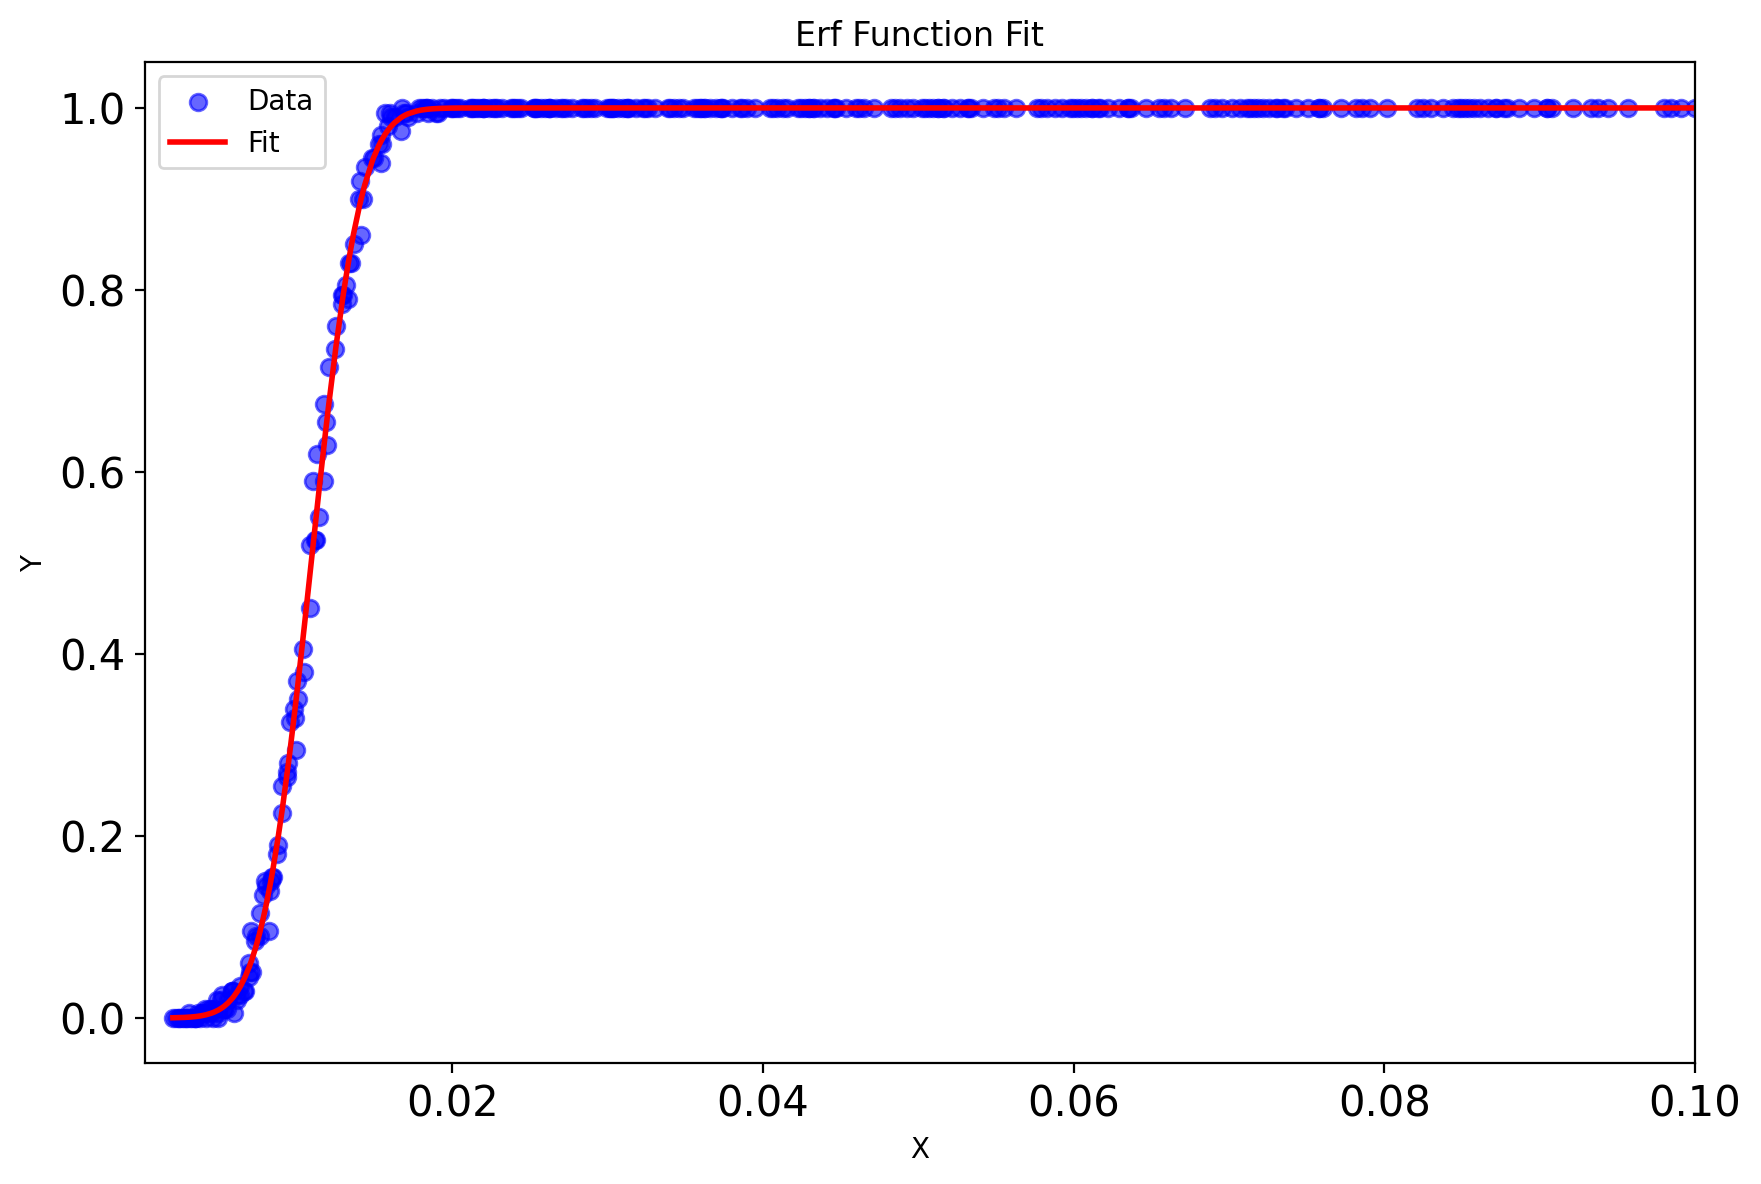

Fitted parameters: a=0.500, b=0.011, c=0.004


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import erf


# Define the erf fit function
def erf_fit(x, a, b, c):
    return a * (1 + erf((x - b) / c))

# Fit the function to the data
popt, pcov = curve_fit(erf_fit, XY_unique*1e6, Z_mean, p0=[0.5, 0, 0.3])

# Generate fitted values

y_fit = erf_fit(XY_unique*1e6, *popt)

# Plot data and fit
plt.scatter(XY_unique*1e6, Z_mean, label='Data', color='blue', alpha=0.6)
plt.plot(XY_unique*1e6, y_fit, label='Fit', color='red', linewidth=2)
plt.legend()
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Erf Function Fit")

plt.xlim(0.2*1e-9*1e6,0.1e-6*1e6)
plt.show()


plt.show()

# Print fitted parameters
print(f"Fitted parameters: a={popt[0]:.3f}, b={popt[1]:.3f}, c={popt[2]:.3f}")


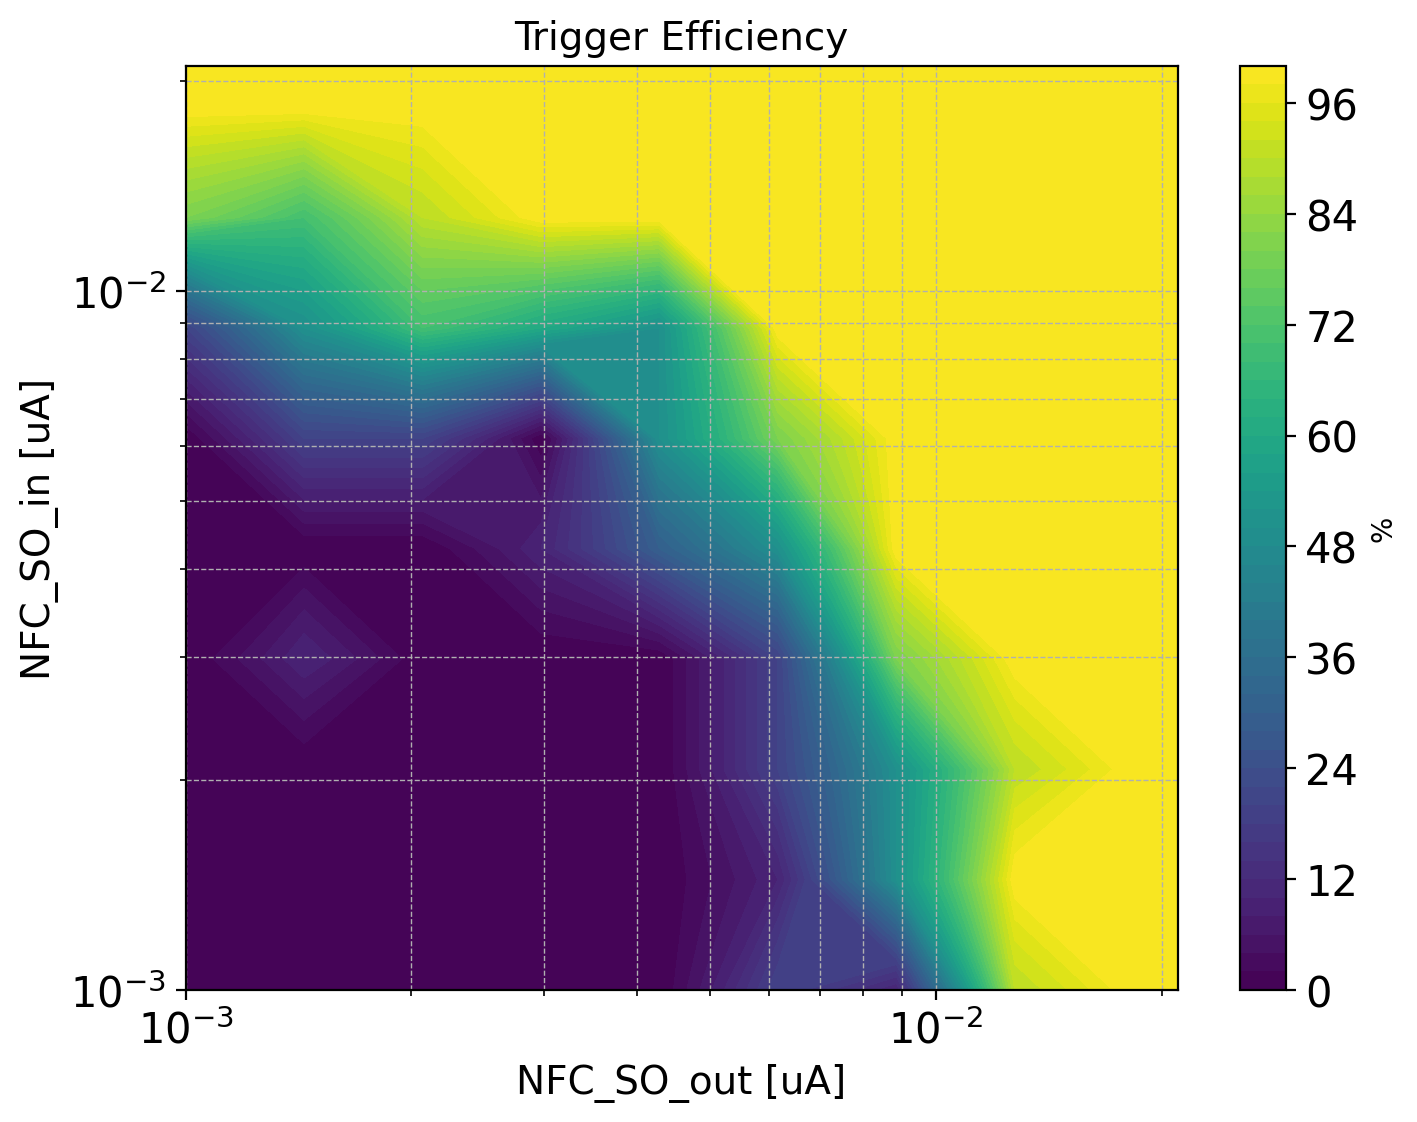

In [ ]:
# Plot the grid
plt.figure(figsize=(8, 6))
plt.contourf(X*1e6, Y*1e6, Z, levels=50, cmap="viridis")  # Filled contour plot
#contour = plt.contourf(X, Y, Z, levels=50, cmap="viridis", norm=LogNorm(vmin=1e-1, vmax=Z.max()))

# Set log scale
plt.xscale("log")
plt.yscale("log")

# Add labels and title
plt.xlabel("NFC_SO_out [uA]", fontsize=14)
plt.ylabel("NFC_SO_in [uA]", fontsize=14)
plt.title("Trigger Efficiency", fontsize=14)

# Add colorbar
plt.colorbar(label="%")
plt.xlim(1e-9*1e6,2.1*1e-8*1e6)
plt.ylim(1e-9*1e6,2.1*1e-8*1e6)
plt.grid(visible=True, which="both", linestyle="--", linewidth=0.5)
plt.show()

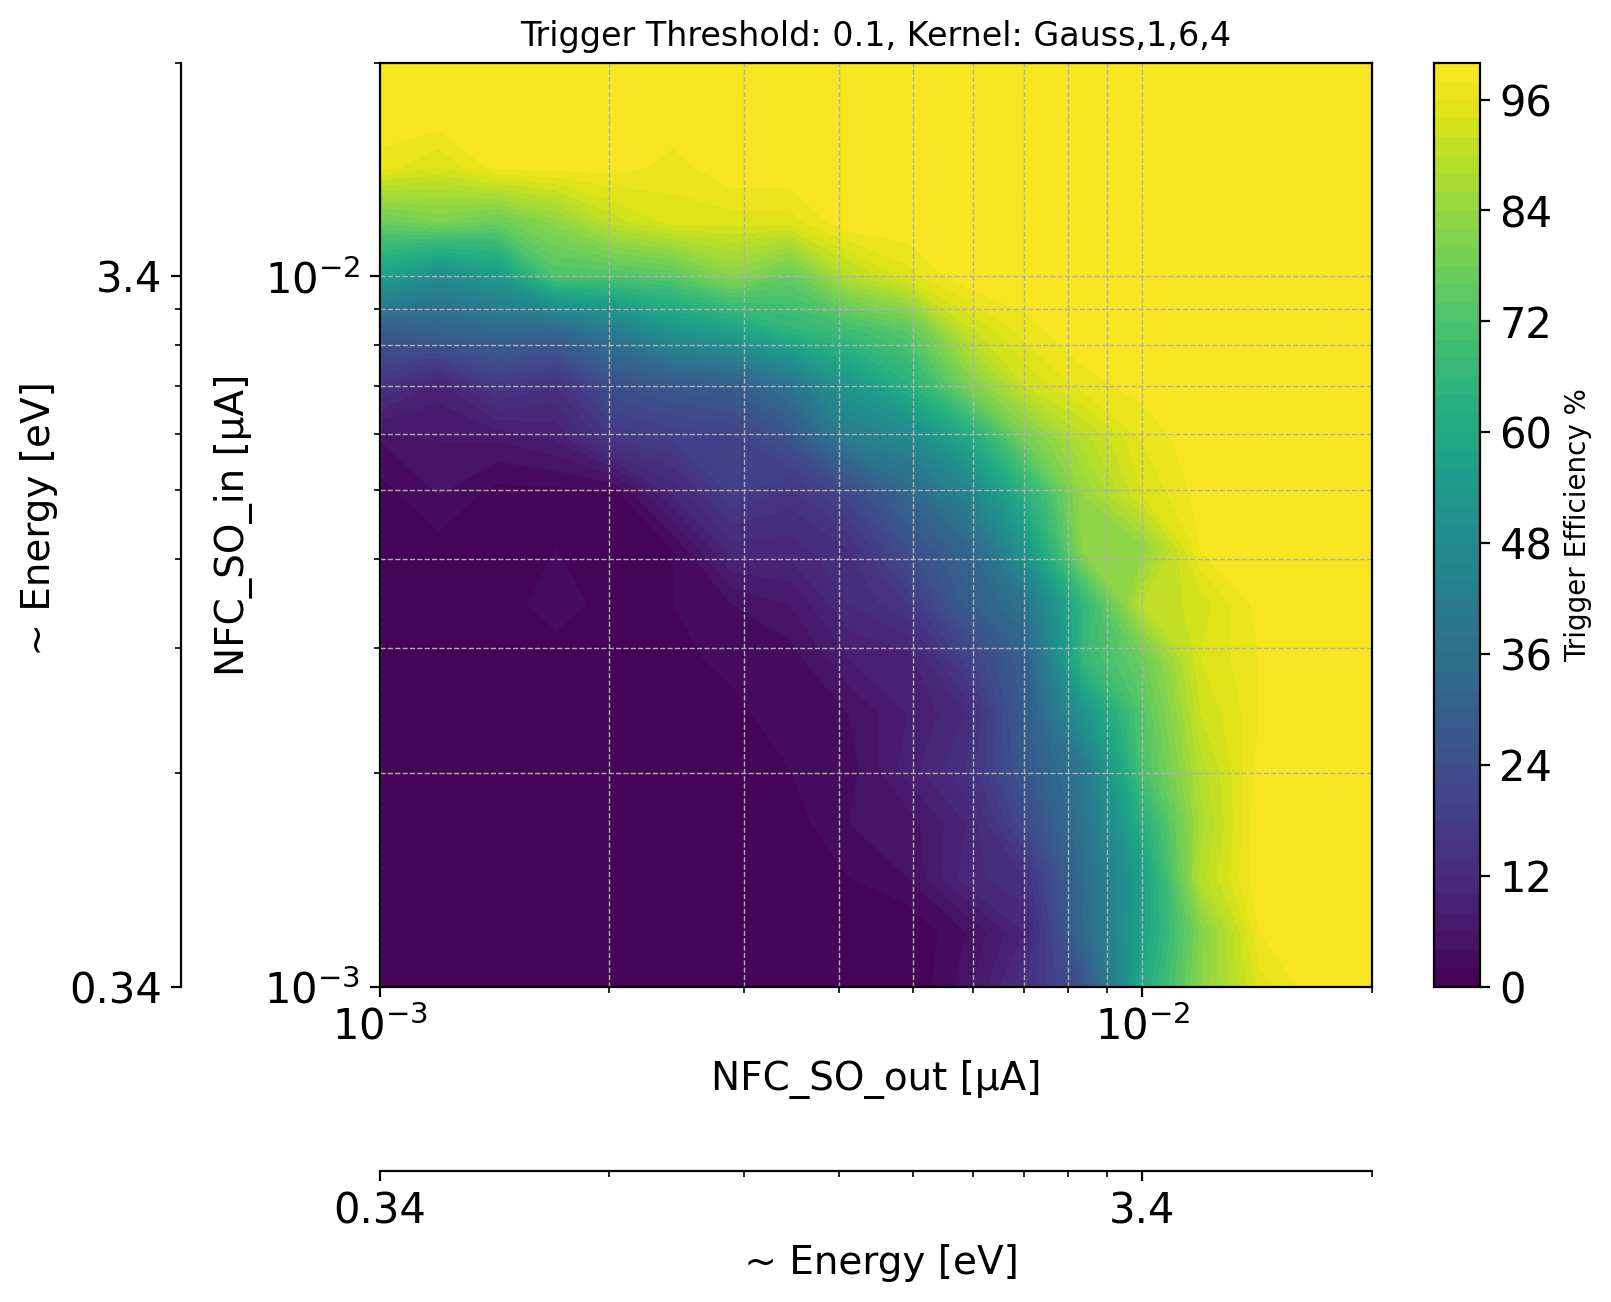

In [ ]:
# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))

# Main contour plot
contour = ax.contourf(X * 1e6, Y * 1e6, Z, levels=50, cmap="viridis")
ax.set_xscale("log")
ax.set_yscale("log")

# Add labels and title for the main axes
ax.set_xlabel("NFC_SO_out [µA]", fontsize=14)
ax.set_ylabel("NFC_SO_in [µA]", fontsize=14)
ax.set_title("Trigger Threshold: " +str(trig_th) +", Kernel: "+config.trigger_kernel )

# Set x and y limits
ax.set_xlim(1e-9 * 1e6, 2.0e-8 * 1e6)
ax.set_ylim(1e-9 * 1e6, 2.0e-8 * 1e6)

# Add grid
ax.grid(visible=True, which="both", linestyle="--", linewidth=0.5)

# Add a duplicate x-axis below the current one
ax_bottom = ax.secondary_xaxis(-0.2)
ax_bottom.set_xscale("log")
ax_bottom.set_xlim(ax.get_xlim())

# Multiply tick marks by 0.34 for the bottom x-axis
ax_bottom.set_xticks(ax.get_xticks())
ax_bottom.set_xticklabels([f"{tick * 340:.2g}" for tick in ax.get_xticks()])
ax_bottom.set_xlabel(" ~ Energy [eV]", fontsize=14)

# Add a duplicate y-axis to the left of the current one
ax_left = ax.secondary_yaxis(-0.2)
ax_left.set_yscale("log")
ax_left.set_ylim(ax.get_ylim())

# Multiply tick marks by 0.34 for the left y-axis
ax_left.set_yticks(ax.get_yticks())
ax_left.set_yticklabels([f"{tick * 340:.2g}" for tick in ax.get_yticks()])
ax_left.set_ylabel(" ~ Energy [eV]", fontsize=14)

# Add the colorbar
cbar = fig.colorbar(contour, ax=ax, label="Trigger Efficiency %")

plt.show()


In [ ]:
plt.errorbar?

Signature:
plt.errorbar(
    x: 'float | ArrayLike',
    y: 'float | ArrayLike',
    yerr: 'float | ArrayLike | None' = None,
    xerr: 'float | ArrayLike | None' = None,
    fmt: 'str' = '',
    ecolor: 'ColorType | None' = None,
    elinewidth: 'float | None' = None,
    capsize: 'float | None' = None,
    barsabove: 'bool' = False,
    lolims: 'bool | ArrayLike' = False,
    uplims: 'bool | ArrayLike' = False,
    xlolims: 'bool | ArrayLike' = False,
    xuplims: 'bool | ArrayLike' = False,
    errorevery: 'int | tuple[int, int]' = 1,
    capthick: 'float | None' = None,
    *,
    data=None,
    **kwargs,
) -> 'ErrorbarContainer'
Docstring:
Plot y versus x as lines and/or markers with attached errorbars.

*x*, *y* define the data locations, *xerr*, *yerr* define the errorbar
sizes. By default, this draws the data markers/lines as well as the
errorbars. Use fmt='none' to draw errorbars without any data markers.

.. versionadded:: 3.7
   Caps and error lines are drawn in polar coordi

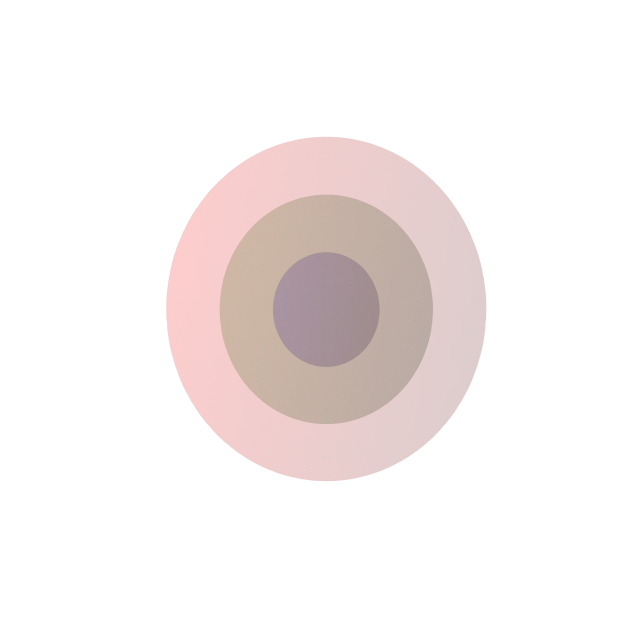

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Function to generate a sphere
def generate_sphere(radius, num_points=100):
    u = np.linspace(0, 2 * np.pi, num_points)
    v = np.linspace(0, np.pi, num_points)
    x = radius * np.outer(np.cos(u), np.sin(v))
    y = radius * np.outer(np.sin(u), np.sin(v))
    z = radius * np.outer(np.ones(np.size(u)), np.cos(v))
    return x, y, z

# Create figure
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

# Define sphere radii (smallest to largest)
radii = [3, 2, 1]
colors = ['r', 'g', 'b']  # Colors for each sphere

# Plot spheres with cross-section removed
for i, (r, color) in enumerate(zip(radii, colors)):
    x, y, z = generate_sphere(r)

    # Apply mask: remove right half (x > 0)
    mask = x > 0  # Keep only the left half
    #x[mask] = np.nan
    #y[mask] = np.nan
    #z[mask] = np.nan

    ax.plot_surface(x, y, z, color=color, linewidth=0.3, alpha=0.1)

# Remove axes and labels
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.axis("off")

# Equal aspect ratio to maintain correct sphere proportions
ax.set_box_aspect([1, 1, 1])

plt.show()
